# Correlation Analysis of Numerical Features

This notebook analyzes linear correlations between numerical features in the
IBM Telco Customer Churn dataset. Correlation analysis is limited to numerical
variables, as correlation metrics are not suitable for categorical features.

In [5]:
import sys
from pathlib import Path

# Add project root to PYTHONPATH
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils.config import PROCESSED_DATA_PATH

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

## Data Loading

In [7]:
df = pd.read_csv(PROCESSED_DATA_PATH / "telco_customer_churn_validated.csv")

## Data Preparation
To enable correlation analysis, `TotalCharges` is temporarily converted to a numeric
type. 

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

numeric_df = df[numeric_cols].copy()
numeric_df["TotalCharges"] = pd.to_numeric(numeric_df["TotalCharges"], errors="coerce")

## Correlation Analysis

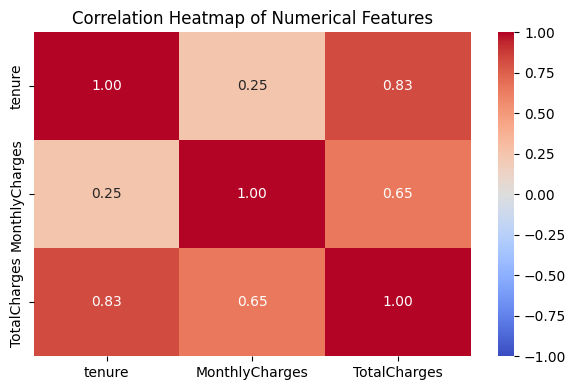

In [9]:
corr = numeric_df.corr(method="pearson")

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## Correlation Key Findings

- **tenure vs TotalCharges (strong positive correlation)**  
  This strong relationship is expected, as customers with longer tenure
  accumulate charges over a longer period of time.

- **MonthlyCharges vs TotalCharges (moderate positive correlation)**  
  MonthlyCharges contributes directly to TotalCharges; however, the relationship
  is moderated by customer tenure, as high monthly charges over a short tenure
  result in lower total charges.

- **tenure vs MonthlyCharges (weak positive correlation)**  
  The weak correlation suggests that how long a customer stays is largely
  independent of how much they are charged monthly.
